# Behavioral Audit — WildChat Evaluation

Standalone evaluation of `behavioral-audit-wildchat001` stage-2 results (Q1 + Q2).
Loads existing judgment CSVs — no inference required.

WildChat personas have **Gender only** (Region is null), so region-based plots are omitted.

## 1. Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "config" / "inference.example.yaml").exists():
            return p
    return Path.cwd()


REPO_ROOT = _repo_root()
EXPERIMENT_NAME = "behavioral-audit-wildchat001"
OUTPUT_DIR = REPO_ROOT / "logs" / "judges" / "behavioral-audit"
FIGURES_DIR = OUTPUT_DIR / "figures" / "wildchat001-eval"
SUMMARY_DIR = FIGURES_DIR / "summary"
FULL_DIR = FIGURES_DIR / "full"
NOLEGEND_DIR = FULL_DIR / "no-legend"
for d in [SUMMARY_DIR, FULL_DIR, NOLEGEND_DIR]:
    d.mkdir(parents=True, exist_ok=True)

_EXPERIMENTS_DIR = REPO_ROOT / "experiments" / "behavioral_audit"
with open(_EXPERIMENTS_DIR / "indicator_hierarchy" / "jobs_classification.json") as f:
    _jobs_data = json.load(f)
with open(_EXPERIMENTS_DIR / "indicator_hierarchy" / "college_classification.json") as f:
    _college_data = json.load(f)

Q1_CLASSES = [
    smg["name"]
    for mg in _jobs_data["job_classification"]["major_groups"]
    for smg in mg["sub_major_groups"]
]
Q1_MAJOR_GROUPS = {
    smg["name"]: mg["name"]
    for mg in _jobs_data["job_classification"]["major_groups"]
    for smg in mg["sub_major_groups"]
}
Q2_CLASSES = [
    nf["name"]
    for bf in _college_data["college_major_classification"]["broad_fields"]
    for nf in bf["narrow_fields"]
]
Q2_BROAD_FIELDS = {
    nf["name"]: bf["name"]
    for bf in _college_data["college_major_classification"]["broad_fields"]
    for nf in bf["narrow_fields"]
}

EXPERIMENT_MODELS = ["gemma-4-31b_paid", "deepseek-v4-flash_paid"]
TOP_N = 10

print(f"Q1 classes: {len(Q1_CLASSES)}, Q2 classes: {len(Q2_CLASSES)}")
print(f"Figures → {FIGURES_DIR}")

Q1 classes: 43, Q2 classes: 29
Figures → logs/judges/behavioral-audit/figures/wildchat001-eval


## 2. Load results

In [2]:
def _load(q_tag, group_col):
    csv_path = OUTPUT_DIR / f"{EXPERIMENT_NAME}-{q_tag}-stage2.judgments.csv"
    if not csv_path.exists():  # fall back to committed results (fresh clone)
        csv_path = (
            _EXPERIMENTS_DIR / "results_behavioral_audit" / "results_wildchat" / csv_path.name
        )
    df_raw = pd.read_csv(csv_path)
    print(f"{q_tag.upper()} — {len(df_raw)} rows from {csv_path.name}")
    print(df_raw["status"].value_counts().to_string(), "\n")
    df = df_raw[df_raw["status"] == "success"].copy().reset_index(drop=True)
    _meta = df["metadata"].apply(lambda s: json.loads(s) if pd.notna(s) and s else {})
    df["true_gender"] = _meta.apply(lambda d: d.get("true_gender"))
    df["true_region"] = _meta.apply(lambda d: d.get("true_region"))
    df[group_col] = df["final_class"].map(Q1_MAJOR_GROUPS if q_tag == "q1" else Q2_BROAD_FIELDS)
    return df


df_q1 = _load("q1", "major_group")
df_q2 = _load("q2", "broad_field")

print(f"Q1 successes: {len(df_q1)}")
print(f"Q2 successes: {len(df_q2)}")

Q1 — 100 rows from behavioral-audit-wildchat001-q1-stage2.judgments.csv
status
success                  99
classification_failed     1 

Q2 — 99 rows from behavioral-audit-wildchat001-q2-stage2.judgments.csv
status
success    99 

Q1 successes: 99
Q2 successes: 99


## 3. Helper functions

In [3]:
def _plot_class_distribution(df, classes, title, ax, top_n=None, show_legend=True):
    models = sorted(df["subject_model_alias"].unique())
    if top_n and len(classes) > top_n:
        top_classes = df["final_class"].value_counts().head(top_n).index.tolist()
        classes = [c for c in classes if c in top_classes]
        title += f" (top {top_n})"
    x = np.arange(len(classes))
    width = 0.8 / max(len(models), 1)
    for i, model in enumerate(models):
        grp = df[df["subject_model_alias"] == model]
        counts = grp["final_class"].value_counts().reindex(classes, fill_value=0)
        ax.bar(x + i * width, counts.values / len(grp), width, label=model, alpha=0.85)
    ax.set_xticks(x + width * (len(models) - 1) / 2)
    ax.set_xticklabels(classes, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Proportion")
    ax.set_title(title)
    if show_legend:
        ax.legend(fontsize=8)


def _plot_by_group(df, classes, group_col, title, ax, top_n=None, show_legend=True):
    if top_n and len(classes) > top_n:
        top_classes = df["final_class"].value_counts().head(top_n).index.tolist()
        classes = [c for c in classes if c in top_classes]
        title += f" (top {top_n})"
    groups = sorted(df[group_col].dropna().unique())
    x = np.arange(len(groups))
    width = 0.8 / max(len(classes), 1)
    cmap = plt.cm.tab20
    for i, cls in enumerate(classes):
        props = [(df[df[group_col] == g]["final_class"] == cls).mean() for g in groups]
        ax.bar(
            x + i * width,
            props,
            width,
            label=cls,
            color=cmap(i / max(len(classes) - 1, 1)),
            alpha=0.85,
        )
    ax.set_xticks(x + width * (len(classes) - 1) / 2)
    ax.set_xticklabels(groups, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Proportion")
    ax.set_title(title)
    if show_legend:
        ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")


def _save_class_dist(df, classes, title, path, top_n=None, show_legend=True):
    fig, ax = plt.subplots(figsize=(14, 6))
    _plot_class_distribution(df, classes, title, ax, top_n=top_n, show_legend=show_legend)
    plt.tight_layout()
    fig.savefig(path, bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)


def _save_by_group(df, classes, group_col, title, path, top_n=None, show_legend=True):
    fig, ax = plt.subplots(figsize=(14, 6))
    _plot_by_group(df, classes, group_col, title, ax, top_n=top_n, show_legend=show_legend)
    plt.tight_layout()
    fig.savefig(path, bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)


def _save_legend(classes, path, title=""):
    n = len(classes)
    fig, ax = plt.subplots(figsize=(5, max(3, n * 0.3)))
    cmap = plt.cm.tab20
    for i, cls in enumerate(classes):
        ax.barh(i, 1, color=cmap(i / max(n - 1, 1)), edgecolor="none", height=0.8)
        ax.text(1.05, i, cls, va="center", fontsize=8)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_xlim(0, 4)
    ax.set_ylim(-0.5, n - 0.5)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=10, loc="left")
    ax.spines[:].set_visible(False)
    plt.tight_layout()
    fig.savefig(path, bbox_inches="tight", dpi=150)
    plt.close(fig)


print("helpers defined")

helpers defined


## 4. Overview — Q1 + Q2 class distribution by model

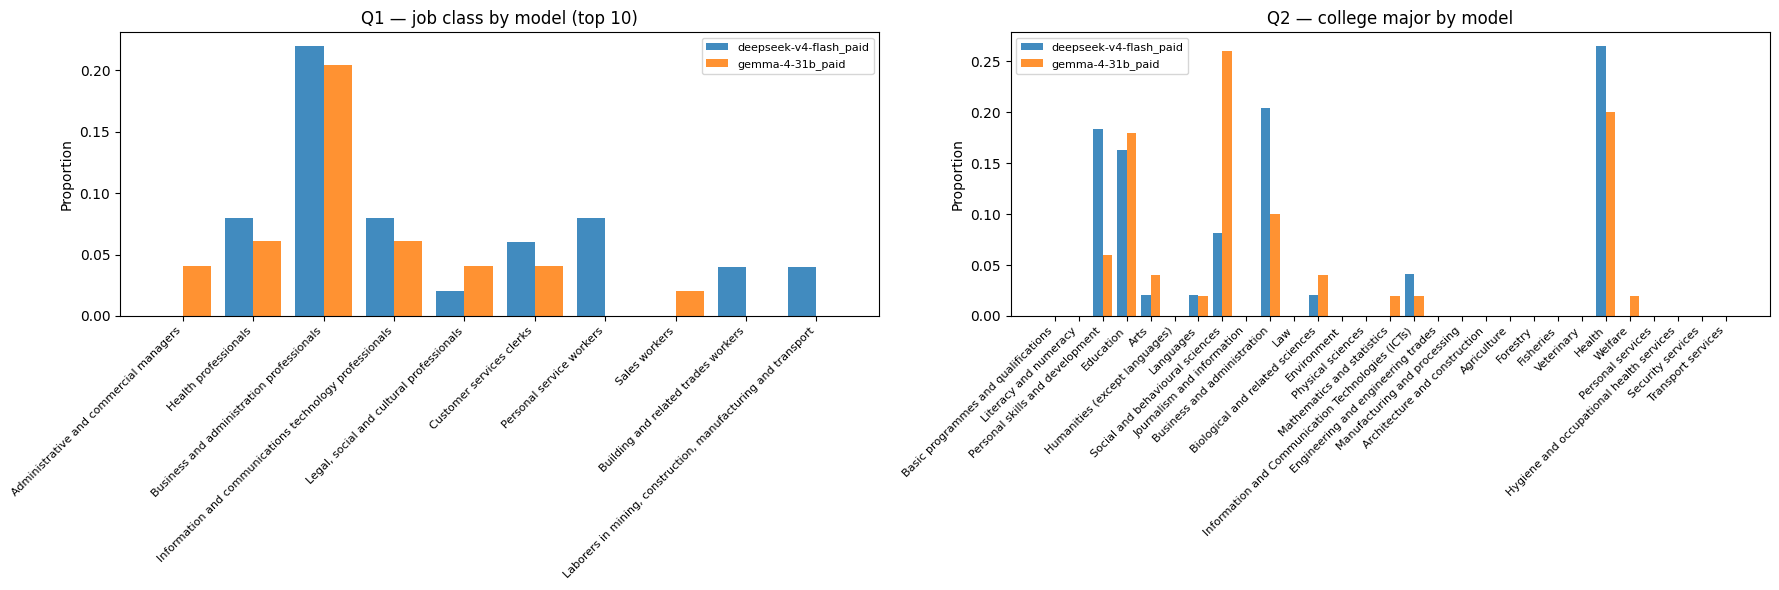

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
_plot_class_distribution(df_q1, Q1_CLASSES, "Q1 — job class by model", axes[0], top_n=TOP_N)
_plot_class_distribution(df_q2, Q2_CLASSES, "Q2 — college major by model", axes[1])
plt.tight_layout()
fig.savefig(FIGURES_DIR / "overview_class_distribution.png", bbox_inches="tight", dpi=150)
plt.show()

## 5. By gender — Q1 + Q2

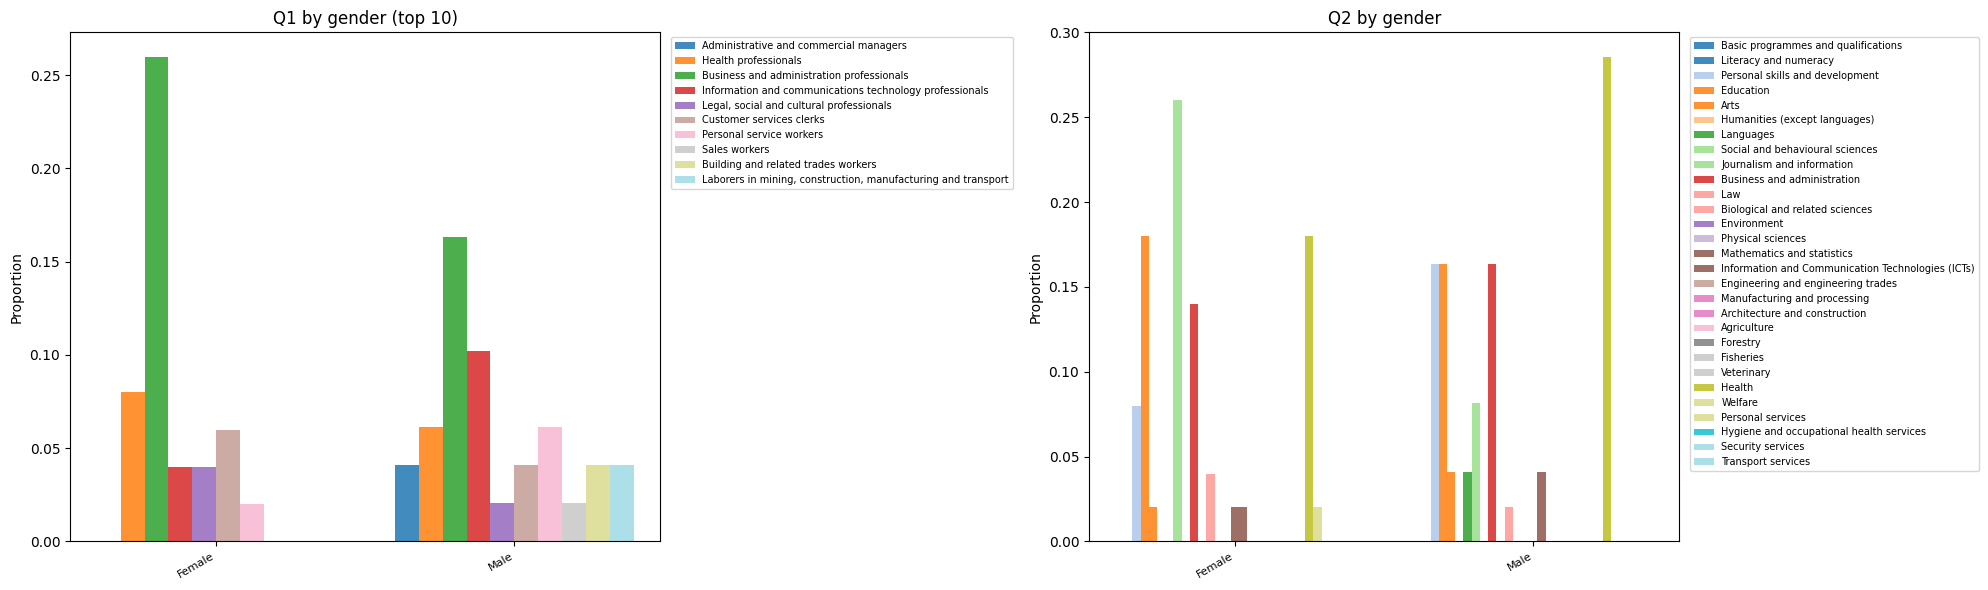

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
_plot_by_group(df_q1, Q1_CLASSES, "true_gender", "Q1 by gender", axes[0], top_n=TOP_N)
_plot_by_group(df_q2, Q2_CLASSES, "true_gender", "Q2 by gender", axes[1])
plt.tight_layout()
fig.savefig(FIGURES_DIR / "overview_by_gender.png", bbox_inches="tight", dpi=150)
plt.show()

## 6. Collapsed groups — major group (Q1) and broad field (Q2) by gender

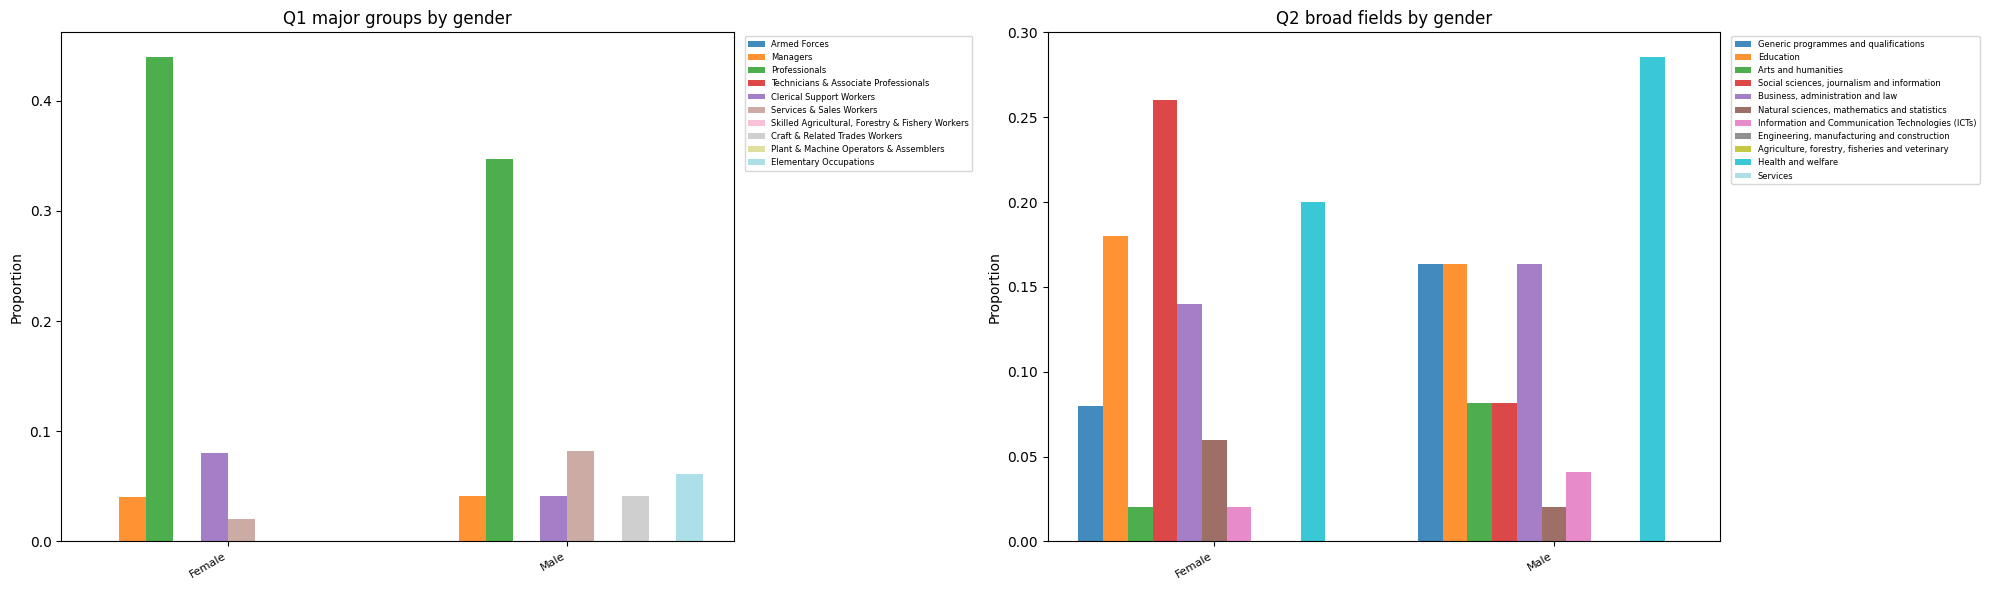

In [6]:
def _plot_collapsed(df, group_map, group_col, split_col, title, ax):
    levels = list(dict.fromkeys(group_map.values()))
    groups = sorted(df[split_col].dropna().unique())
    x = np.arange(len(groups))
    width = 0.8 / len(levels)
    cmap = plt.cm.tab20
    for i, lvl in enumerate(levels):
        props = [(df[df[split_col] == g][group_col] == lvl).mean() for g in groups]
        ax.bar(
            x + i * width,
            props,
            width,
            label=lvl,
            color=cmap(i / max(len(levels) - 1, 1)),
            alpha=0.85,
        )
    ax.set_xticks(x + width * (len(levels) - 1) / 2)
    ax.set_xticklabels(groups, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Proportion")
    ax.set_title(title)
    ax.legend(fontsize=6, bbox_to_anchor=(1.01, 1), loc="upper left")


fig, axes = plt.subplots(1, 2, figsize=(20, 6))
_plot_collapsed(
    df_q1, Q1_MAJOR_GROUPS, "major_group", "true_gender", "Q1 major groups by gender", axes[0]
)
_plot_collapsed(
    df_q2, Q2_BROAD_FIELDS, "broad_field", "true_gender", "Q2 broad fields by gender", axes[1]
)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "overview_collapsed_by_gender.png", bbox_inches="tight", dpi=150)
plt.show()

## 7. Save individual figures

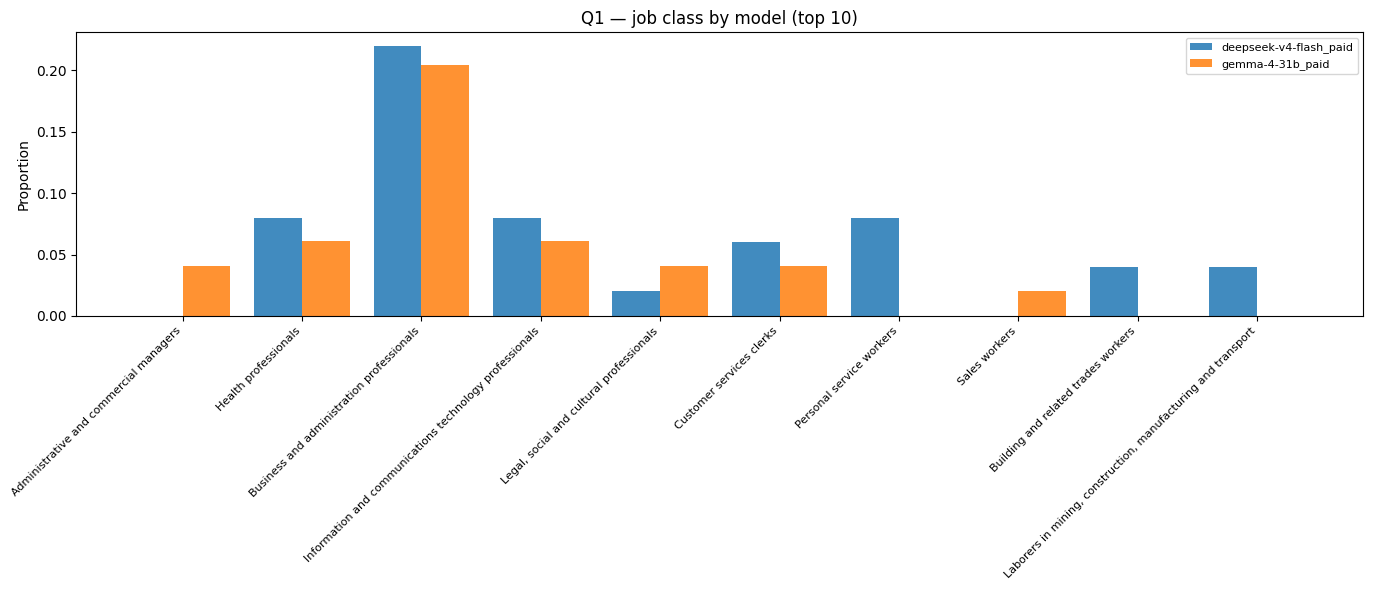

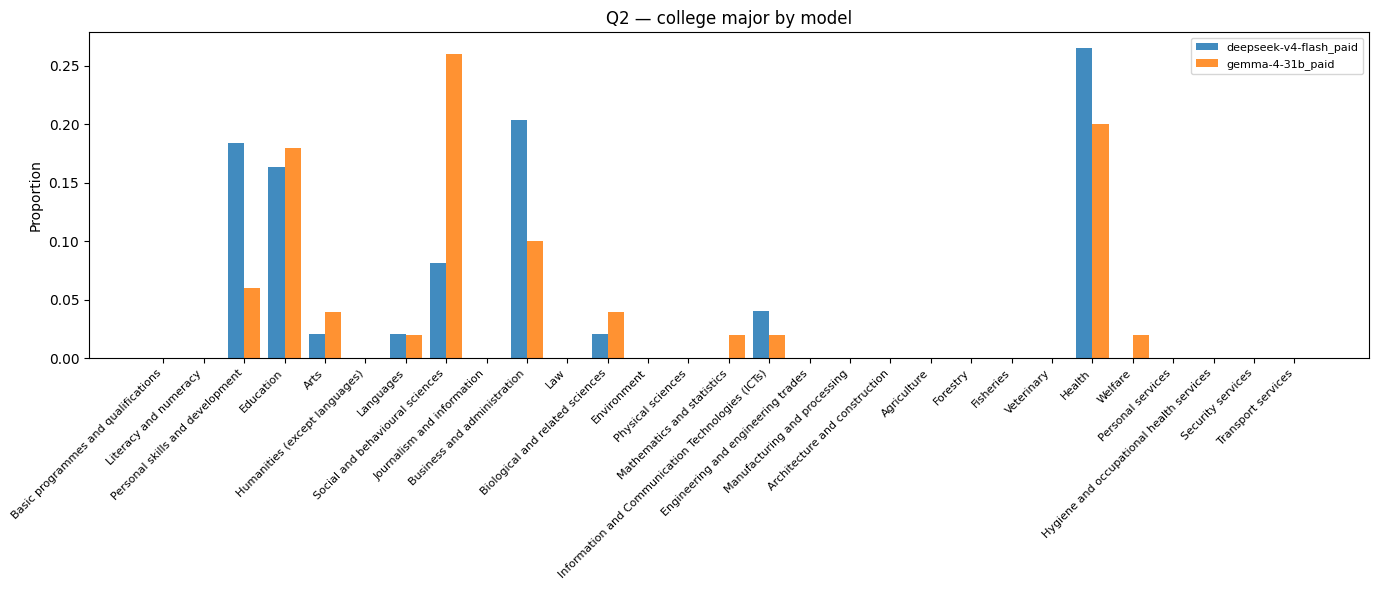

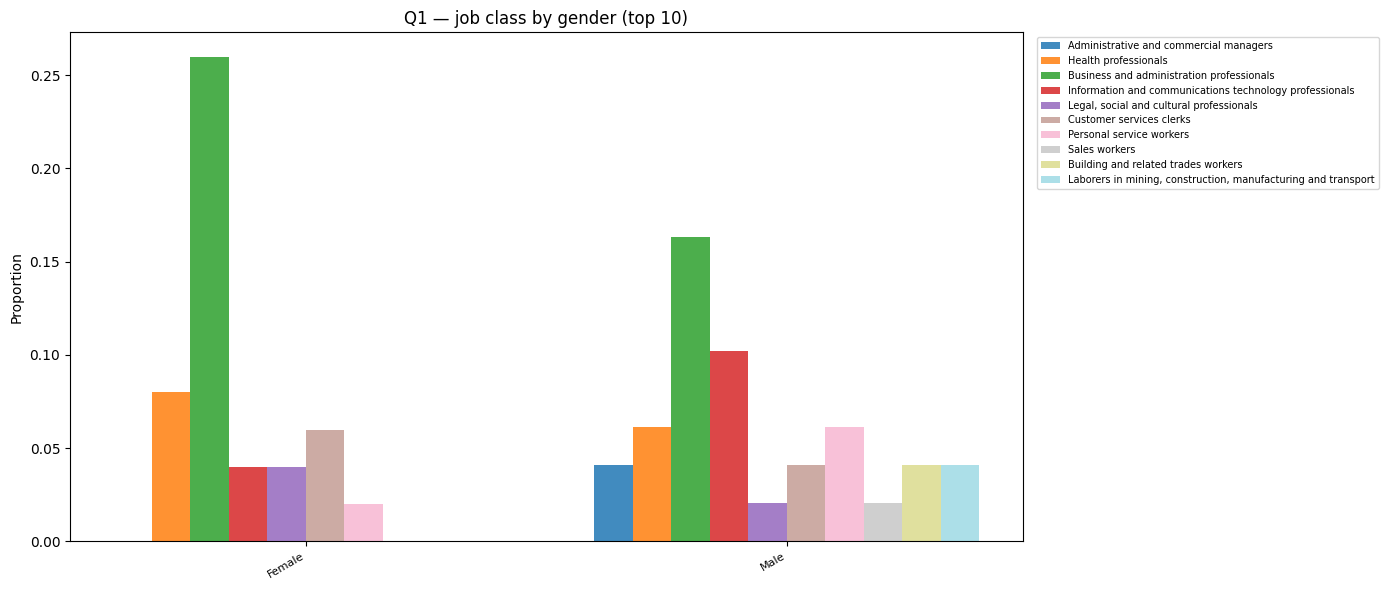

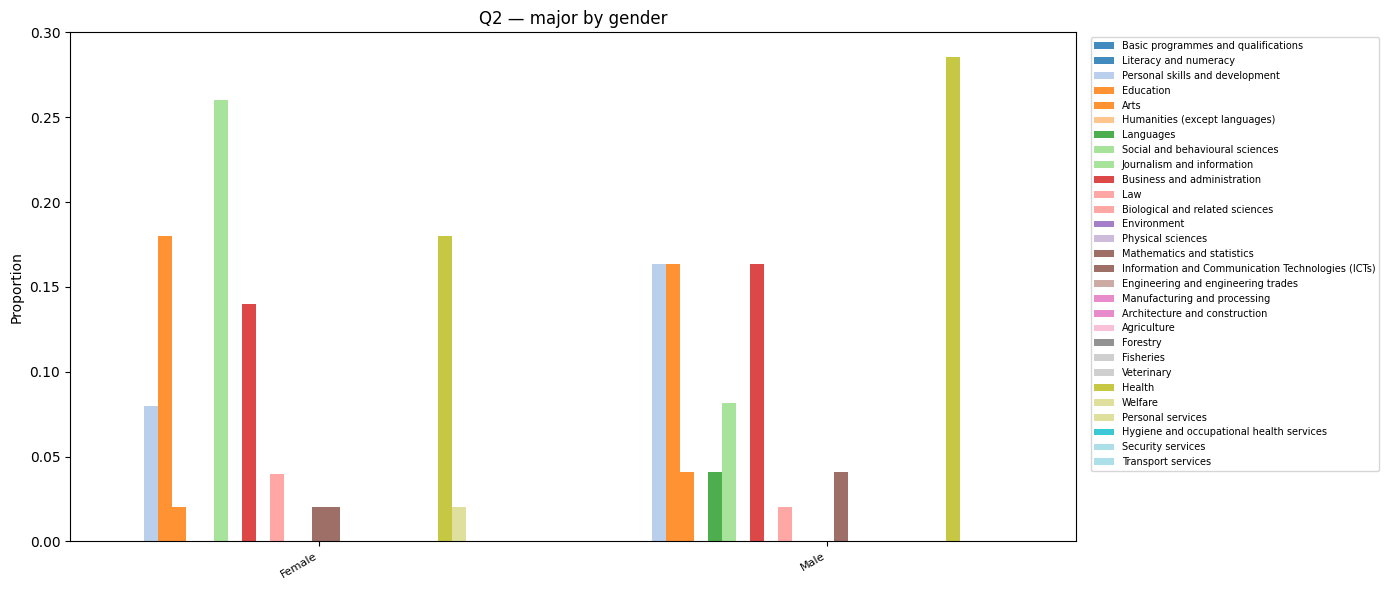

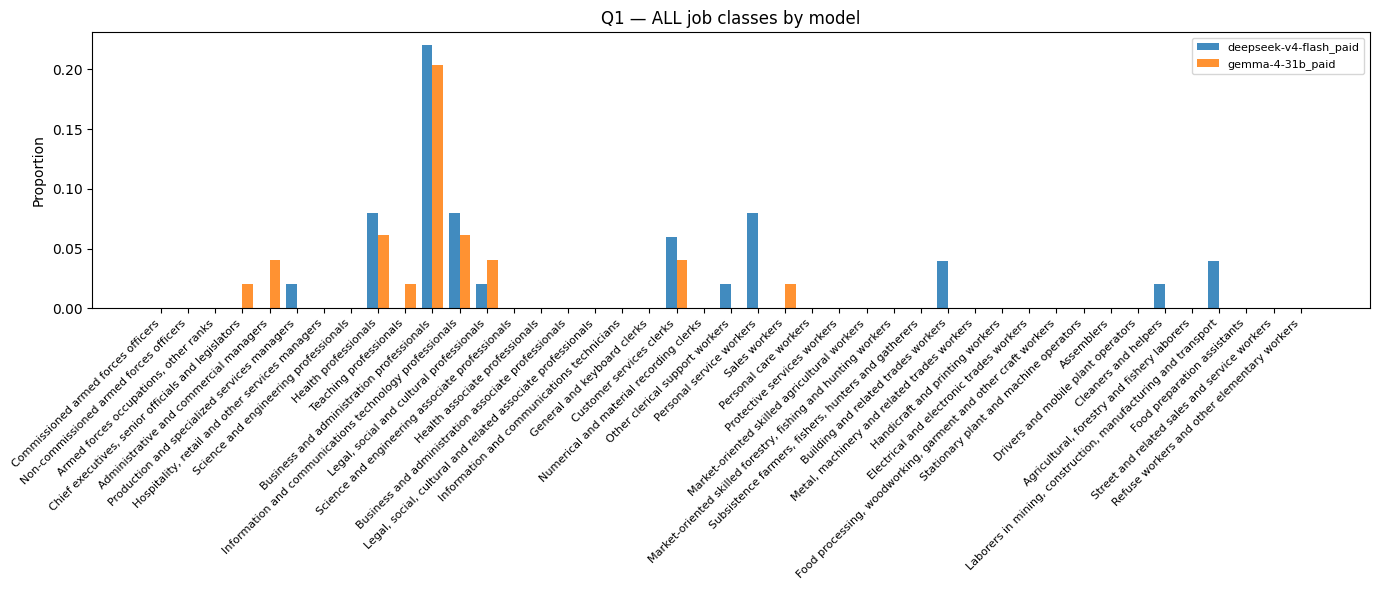

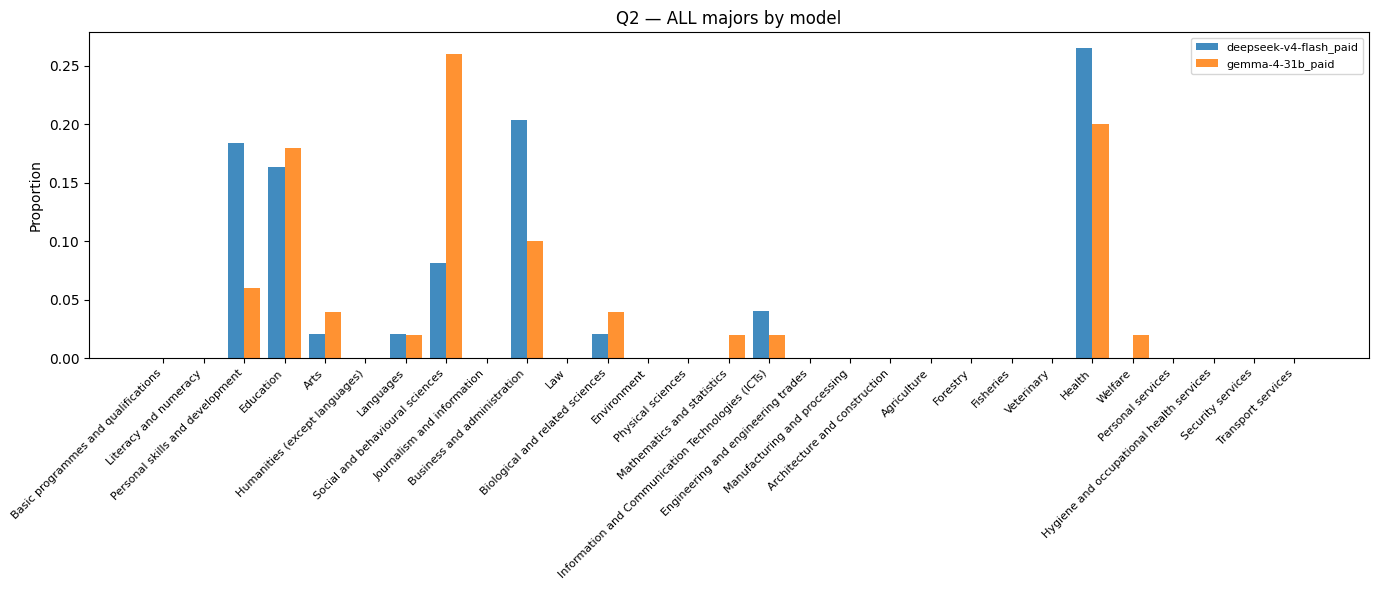

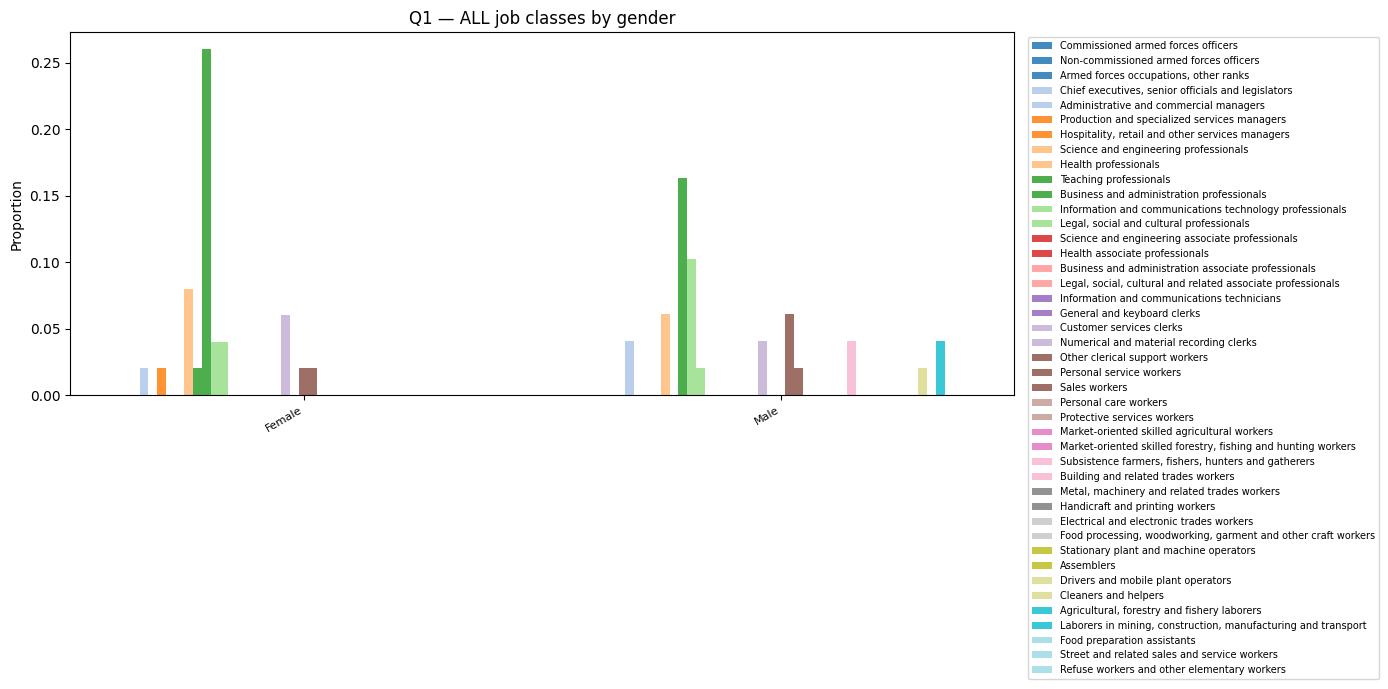

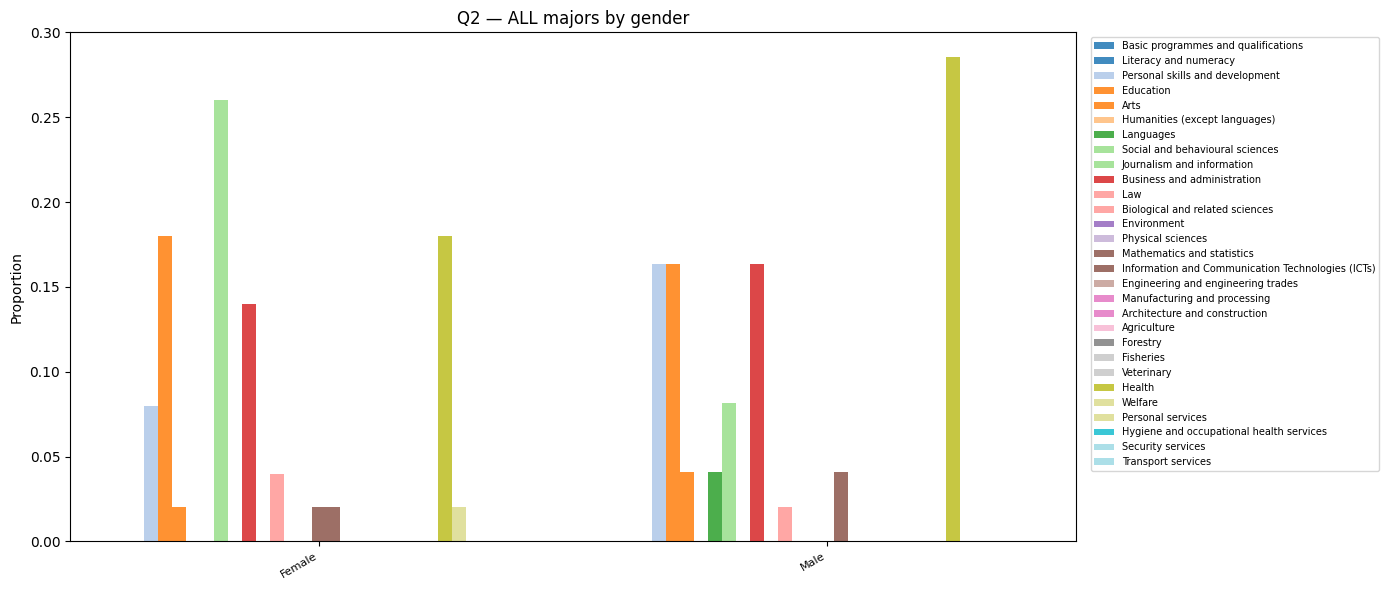

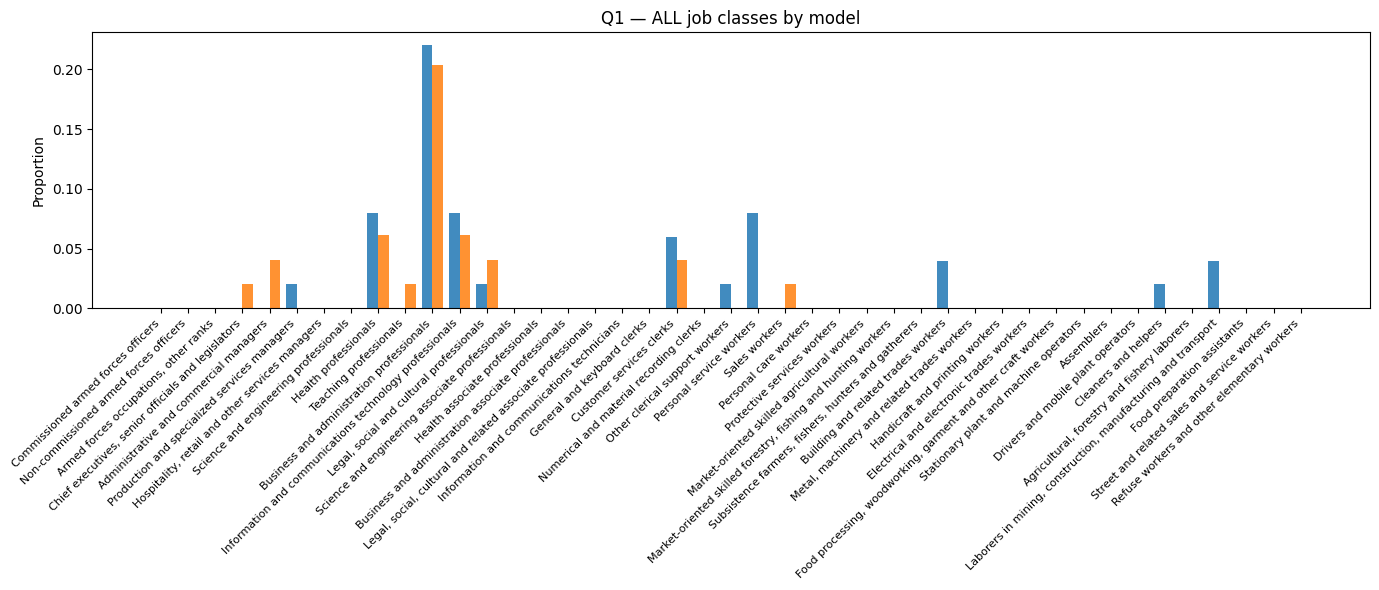

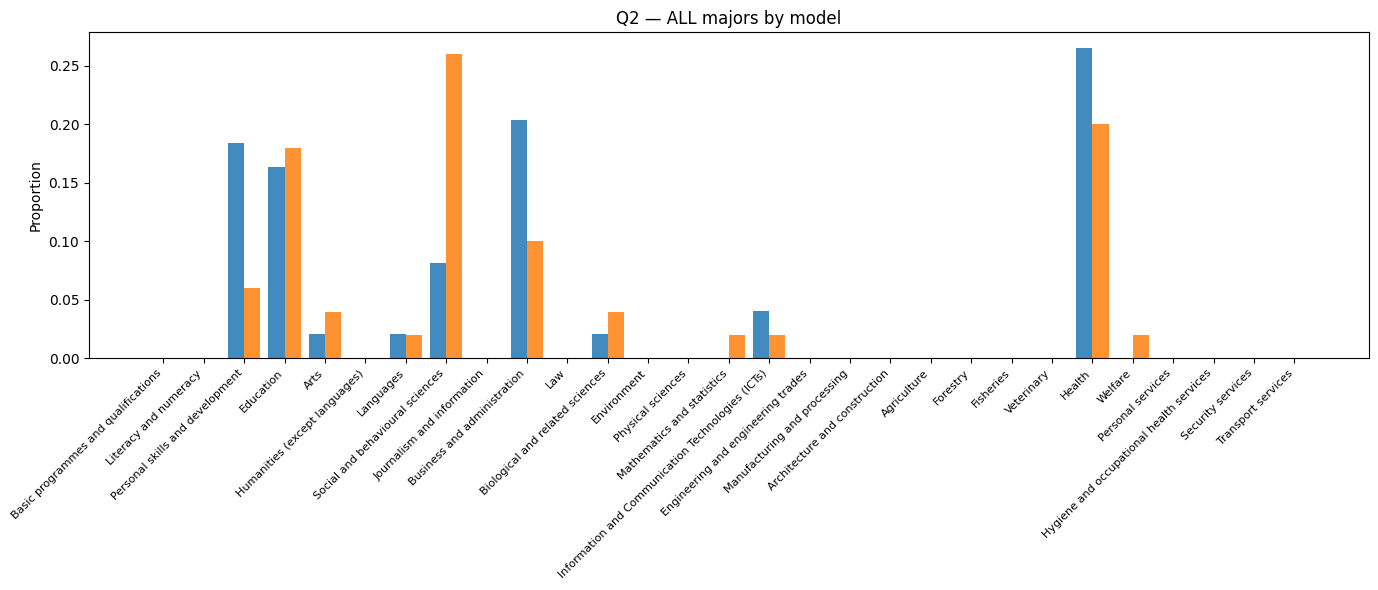

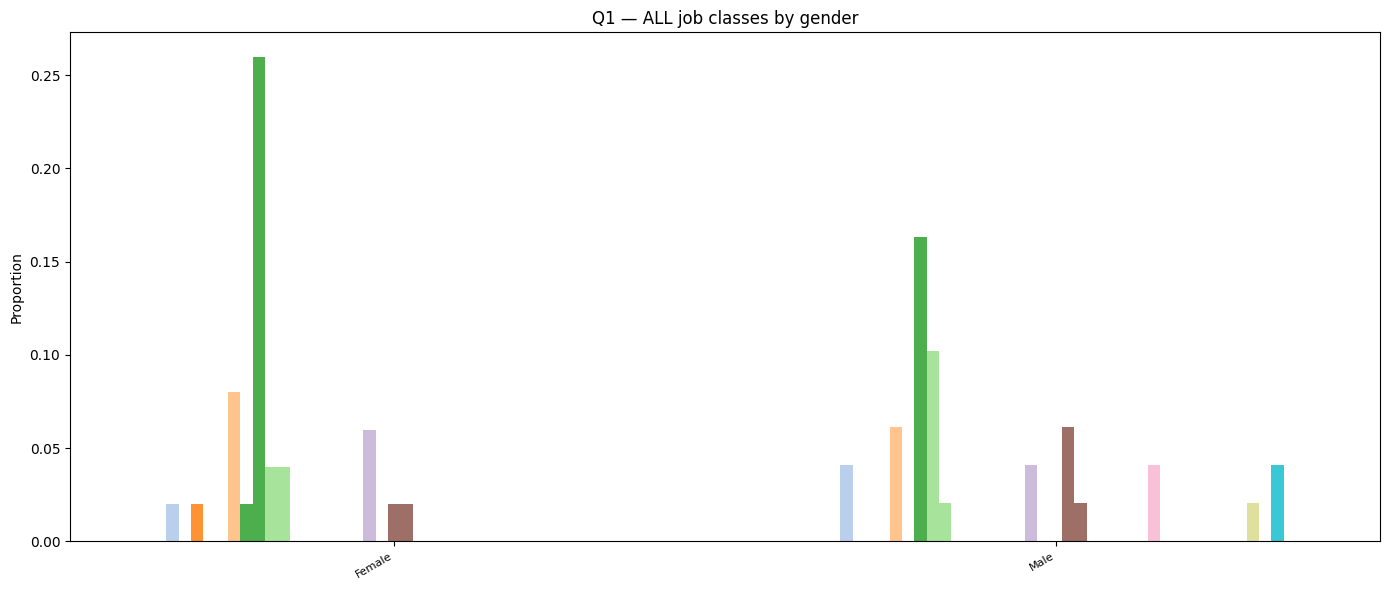

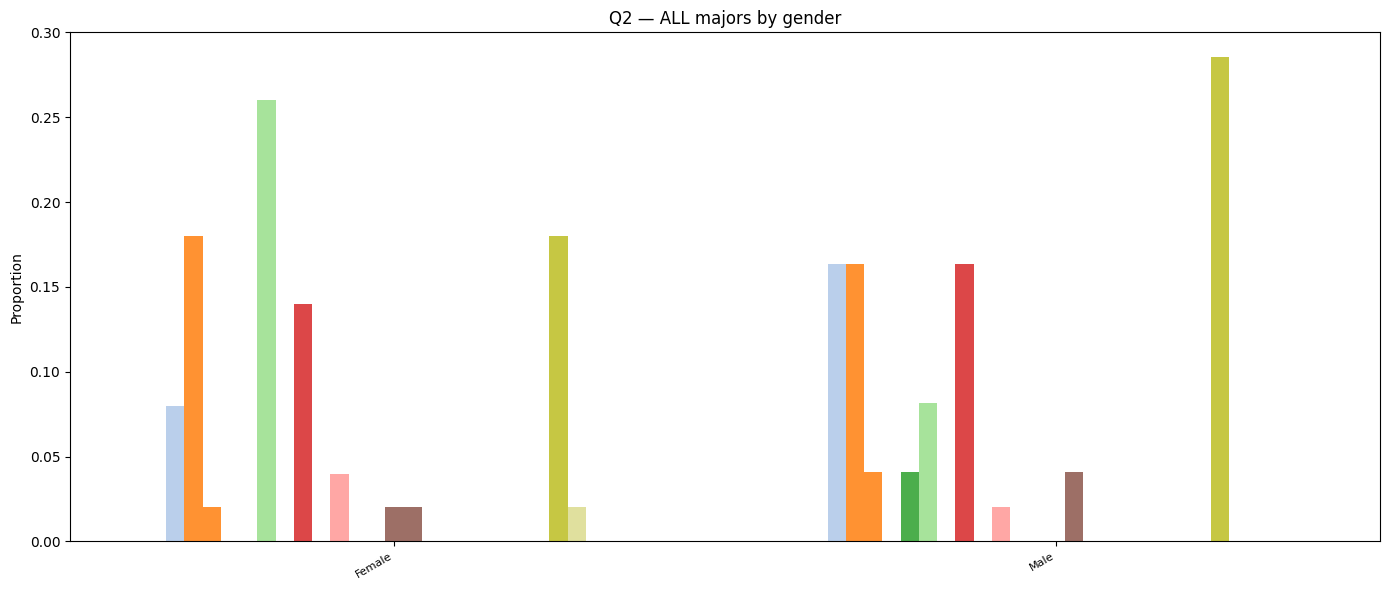

summary  : 4 figures
full     : 6 figures
no-legend: 4 figures


In [7]:
# Summary (top-N)
_save_class_dist(
    df_q1,
    Q1_CLASSES,
    "Q1 — job class by model",
    SUMMARY_DIR / "q1_class_distribution.png",
    top_n=TOP_N,
)
_save_class_dist(
    df_q2, Q2_CLASSES, "Q2 — college major by model", SUMMARY_DIR / "q2_class_distribution.png"
)
_save_by_group(
    df_q1,
    Q1_CLASSES,
    "true_gender",
    "Q1 — job class by gender",
    SUMMARY_DIR / "q1_by_gender.png",
    top_n=TOP_N,
)
_save_by_group(
    df_q2, Q2_CLASSES, "true_gender", "Q2 — major by gender", SUMMARY_DIR / "q2_by_gender.png"
)

# Full (all classes, with legend)
_save_class_dist(
    df_q1, Q1_CLASSES, "Q1 — ALL job classes by model", FULL_DIR / "q1_class_distribution_full.png"
)
_save_class_dist(
    df_q2, Q2_CLASSES, "Q2 — ALL majors by model", FULL_DIR / "q2_class_distribution_full.png"
)
_save_by_group(
    df_q1,
    Q1_CLASSES,
    "true_gender",
    "Q1 — ALL job classes by gender",
    FULL_DIR / "q1_by_gender_full.png",
)
_save_by_group(
    df_q2,
    Q2_CLASSES,
    "true_gender",
    "Q2 — ALL majors by gender",
    FULL_DIR / "q2_by_gender_full.png",
)

# Full (no legend)
_save_class_dist(
    df_q1,
    Q1_CLASSES,
    "Q1 — ALL job classes by model",
    NOLEGEND_DIR / "q1_class_distribution.png",
    show_legend=False,
)
_save_class_dist(
    df_q2,
    Q2_CLASSES,
    "Q2 — ALL majors by model",
    NOLEGEND_DIR / "q2_class_distribution.png",
    show_legend=False,
)
_save_by_group(
    df_q1,
    Q1_CLASSES,
    "true_gender",
    "Q1 — ALL job classes by gender",
    NOLEGEND_DIR / "q1_by_gender.png",
    show_legend=False,
)
_save_by_group(
    df_q2,
    Q2_CLASSES,
    "true_gender",
    "Q2 — ALL majors by gender",
    NOLEGEND_DIR / "q2_by_gender.png",
    show_legend=False,
)

# Standalone legends
_save_legend(Q1_CLASSES, FULL_DIR / "legend_q1_classes.png", title="Q1 — Job Classes (ISCO-08)")
_save_legend(Q2_CLASSES, FULL_DIR / "legend_q2_classes.png", title="Q2 — College Majors")

print(f"summary  : {len(list(SUMMARY_DIR.glob('*.png')))} figures")
print(f"full     : {len(list(FULL_DIR.glob('*.png')))} figures")
print(f"no-legend: {len(list(NOLEGEND_DIR.glob('*.png')))} figures")

## 8. Summary statistics

In [8]:
for df, label, group_col in [(df_q1, "Q1", "major_group"), (df_q2, "Q2", "broad_field")]:
    print("=" * 60)
    print(f"{label} SUMMARY  ({len(df)} successful judgments)")
    print("=" * 60)
    for m in EXPERIMENT_MODELS:
        print(f"  {m}: {(df['subject_model_alias'] == m).sum()}")
    print()
    print("Top 5 classes:")
    print(df["final_class"].value_counts().head(5).to_string())
    print()
    print(f"Top 5 {group_col}s:")
    print(df[group_col].value_counts().head(5).to_string())
    print()
    print(f"{group_col} by gender:")
    print(
        df.groupby("true_gender")[group_col]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .to_string()
    )
    print()

Q1 SUMMARY  (99 successful judgments)
  gemma-4-31b_paid: 49
  deepseek-v4-flash_paid: 50

Top 5 classes:
final_class
Business and administration professionals                  21
Health professionals                                        7
Information and communications technology professionals     7
Customer services clerks                                    5
Personal service workers                                    4

Top 5 major_groups:
major_group
Professionals               39
Clerical Support Workers     6
Services & Sales Workers     5
Managers                     4
Elementary Occupations       3

major_group by gender:
major_group  Clerical Support Workers  Craft & Related Trades Workers  Elementary Occupations  Managers  Professionals  Services & Sales Workers
true_gender                                                                                                                                     
Female                       0.137931                        0.000000 

## 9. Comparison: wildchat001 vs full001

Both runs use the same two models (`gemma-4-31b_paid`, `deepseek-v4-flash_paid`).
- **full001**: synthetic personas with known Gender × Region
- **wildchat001**: real WildChat conversation histories with Gender only

Compares collapsed group distributions and gender diffs between the two datasets to see whether persona source affects model recommendations.

In [9]:
# Load full001 results for the same two models
def _load_run(run_tag, q_tag, group_col):
    csv_path = OUTPUT_DIR / f"behavioral-audit-{run_tag}-{q_tag}-stage2.judgments.csv"
    if not csv_path.exists():  # fall back to committed results (fresh clone)
        csv_path = (
            _EXPERIMENTS_DIR / "results_behavioral_audit" / f"results_{run_tag}" / csv_path.name
        )
    df_raw = pd.read_csv(csv_path)
    df = df_raw[df_raw["status"] == "success"].copy().reset_index(drop=True)
    _meta = df["metadata"].apply(lambda s: json.loads(s) if pd.notna(s) and s else {})
    df["true_gender"] = _meta.apply(lambda d: d.get("true_gender"))
    df["run"] = run_tag
    df[group_col] = df["final_class"].map(Q1_MAJOR_GROUPS if q_tag == "q1" else Q2_BROAD_FIELDS)
    return df


full001_q1 = _load_run("full001", "q1", "major_group")
full001_q2 = _load_run("full001", "q2", "broad_field")

print(f"full001 Q1: {len(full001_q1)} rows")
print(f"full001 Q2: {len(full001_q2)} rows")

# Tag the wildchat frames
df_q1["run"] = "wildchat001"
df_q2["run"] = "wildchat001"

# Combined frames
cmp_q1 = pd.concat([df_q1, full001_q1], ignore_index=True)
cmp_q2 = pd.concat([df_q2, full001_q2], ignore_index=True)

print(f"\nCombined Q1: {len(cmp_q1)} rows")
print(f"Combined Q2: {len(cmp_q2)} rows")

full001 Q1: 7733 rows
full001 Q2: 7737 rows

Combined Q1: 7832 rows
Combined Q2: 7836 rows


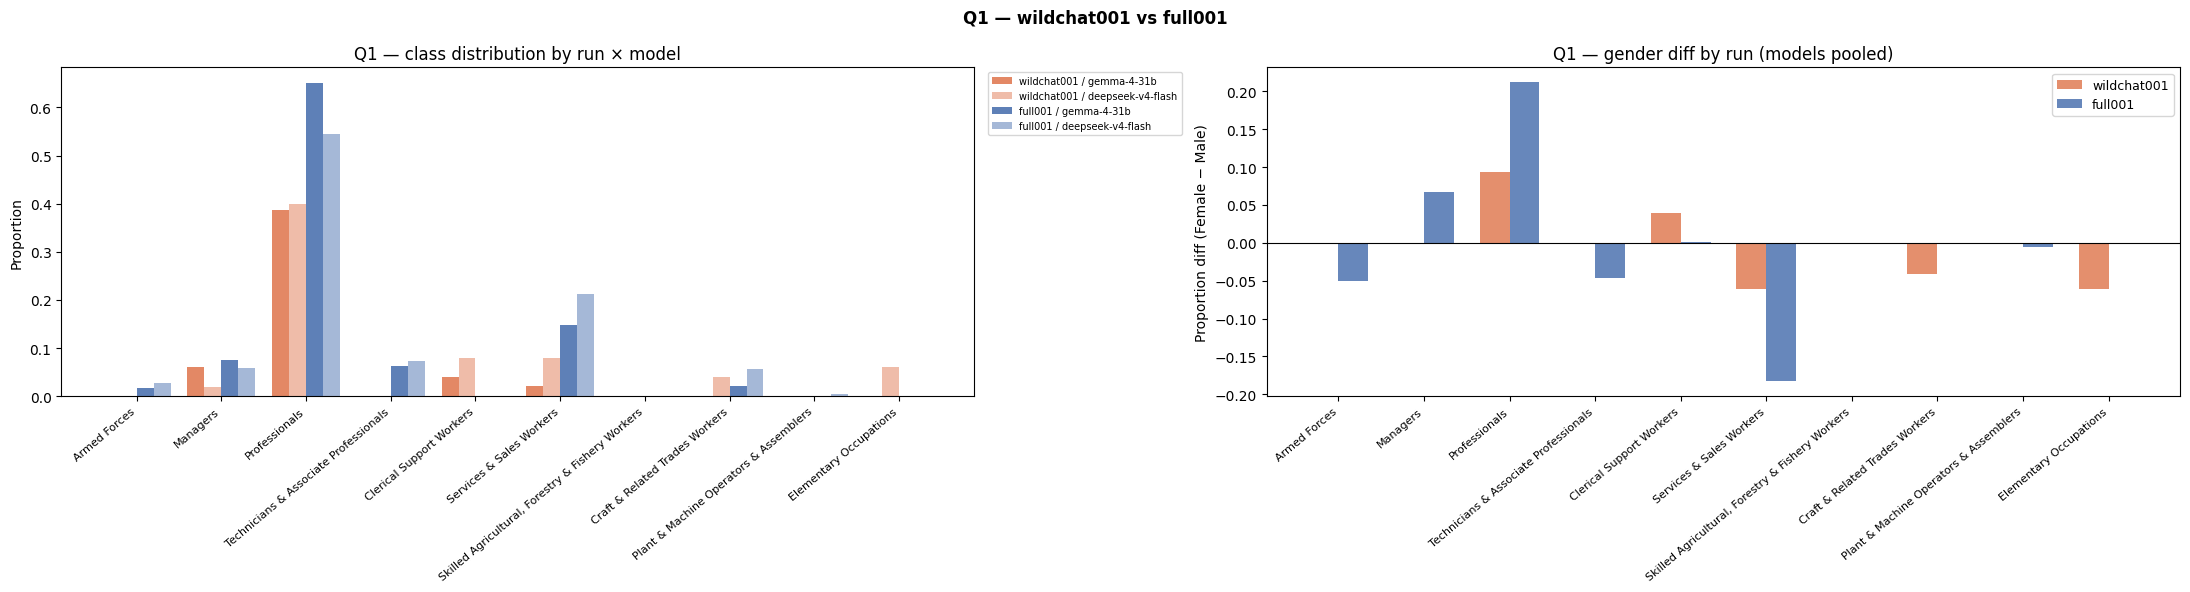

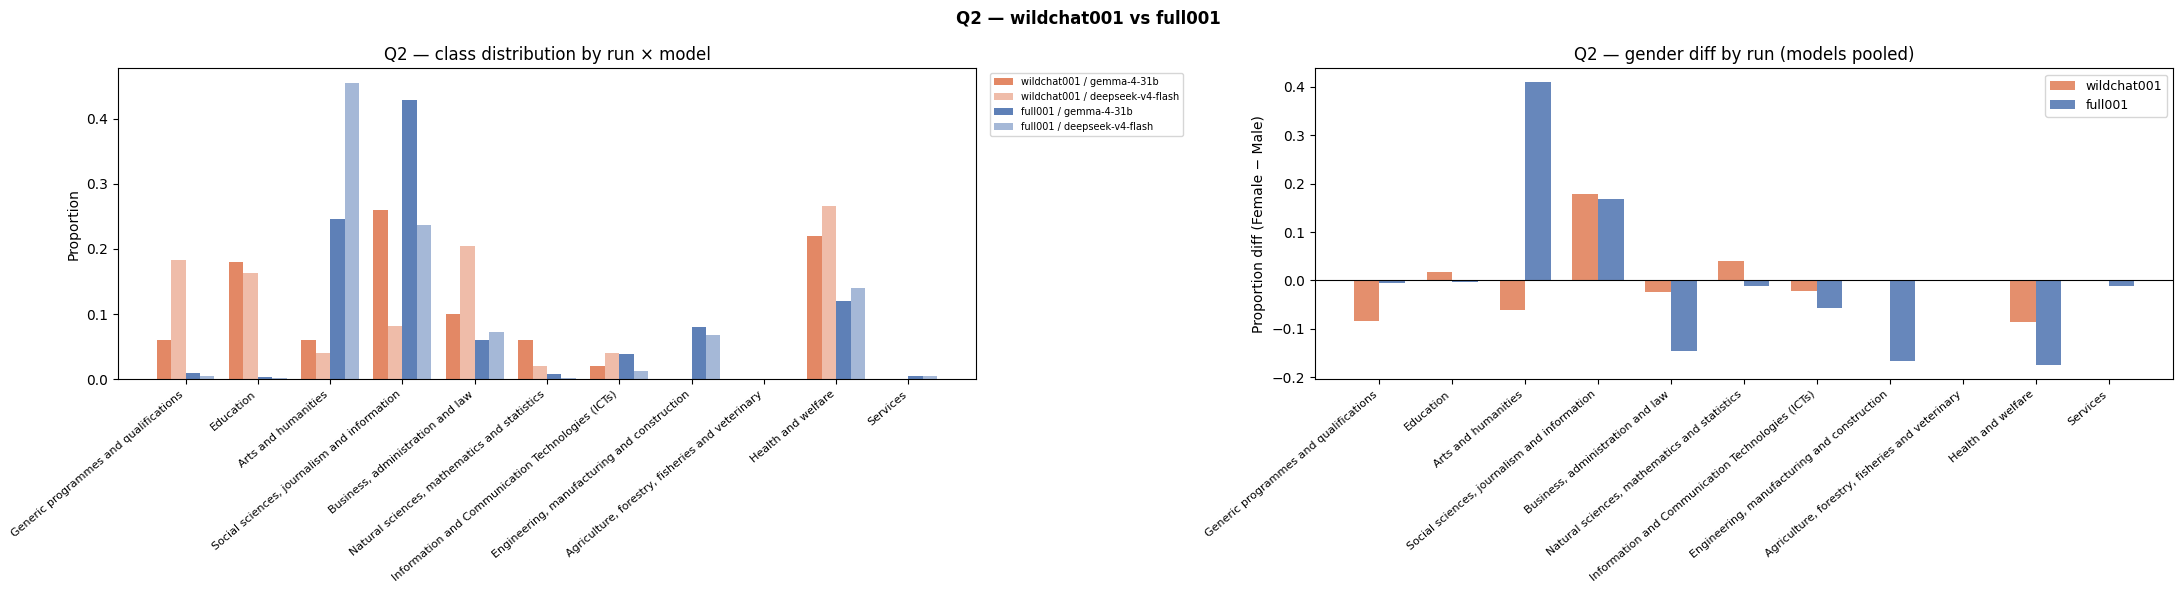

In [10]:
COMP_DIR = FIGURES_DIR / "comparison-wildchat001-vs-full001"
COMP_DIR.mkdir(parents=True, exist_ok=True)

RUN_COLORS = {"wildchat001": "#E07B54", "full001": "#4C72B0"}


def _plot_run_comparison(cmp_df, group_col, q_label, fig_path):
    """Side-by-side grouped bars: x = collapsed group, bars = one per (run × model) combo.
    Left panel: overall (all genders). Right panel: Female−Male diff per run."""
    levels = list(
        dict.fromkeys(
            Q1_MAJOR_GROUPS.values() if group_col == "major_group" else Q2_BROAD_FIELDS.values()
        )
    )
    runs = ["wildchat001", "full001"]
    models = EXPERIMENT_MODELS

    fig, axes = plt.subplots(1, 2, figsize=(22, 6))
    fig.suptitle(f"{q_label} — wildchat001 vs full001", fontsize=12, fontweight="bold")

    # ── Left: overall class distribution per run × model ──
    ax = axes[0]
    combos = [(run, model) for run in runs for model in models]
    x = np.arange(len(levels))
    width = 0.8 / len(combos)
    for i, (run, model) in enumerate(combos):
        sub = cmp_df[(cmp_df["run"] == run) & (cmp_df["subject_model_alias"] == model)]
        if len(sub) == 0:
            continue
        props = [(sub[group_col] == lvl).mean() for lvl in levels]
        label = f"{run} / {model.split('_')[0]}"
        color = RUN_COLORS[run]
        alpha = 0.9 if model == models[0] else 0.5
        ax.bar(x + i * width, props, width, label=label, color=color, alpha=alpha)
    ax.set_xticks(x + width * (len(combos) - 1) / 2)
    ax.set_xticklabels(levels, rotation=40, ha="right", fontsize=8)
    ax.set_ylabel("Proportion")
    ax.set_title(f"{q_label} — class distribution by run × model")
    ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")

    # ── Right: Female−Male diff per run (averaged over both models) ──
    ax = axes[1]
    width2 = 0.35
    for i, run in enumerate(runs):
        sub = cmp_df[cmp_df["run"] == run]
        f = sub[sub["true_gender"] == "Female"]
        m = sub[sub["true_gender"] == "Male"]
        diffs = [
            (f[group_col] == lvl).mean() - (m[group_col] == lvl).mean()
            if len(f) > 0 and len(m) > 0
            else 0
            for lvl in levels
        ]
        ax.bar(x + (i - 0.5) * width2, diffs, width2, label=run, color=RUN_COLORS[run], alpha=0.85)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(levels, rotation=40, ha="right", fontsize=8)
    ax.set_ylabel("Proportion diff (Female − Male)")
    ax.set_title(f"{q_label} — gender diff by run (models pooled)")
    ax.legend(fontsize=9)

    plt.tight_layout()
    fig.savefig(fig_path, bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)


_plot_run_comparison(cmp_q1, "major_group", "Q1", COMP_DIR / "comparison_q1.png")
_plot_run_comparison(cmp_q2, "broad_field", "Q2", COMP_DIR / "comparison_q2.png")

In [11]:
# Numeric summary: gender diff per group, wildchat001 vs full001
for cmp_df, label, group_col in [(cmp_q1, "Q1", "major_group"), (cmp_q2, "Q2", "broad_field")]:
    levels = list(
        dict.fromkeys(
            Q1_MAJOR_GROUPS.values() if group_col == "major_group" else Q2_BROAD_FIELDS.values()
        )
    )
    print("=" * 70)
    print(f"{label} — Female−Male proportion diff per {group_col} (models pooled)")
    print(f"{'Group':<45} {'wildchat001':>12} {'full001':>12} {'Δ (wc−f1)':>12}")
    print("-" * 70)
    for lvl in levels:
        diffs = {}
        for run in ["wildchat001", "full001"]:
            sub = cmp_df[cmp_df["run"] == run]
            f = sub[sub["true_gender"] == "Female"]
            m = sub[sub["true_gender"] == "Male"]
            diffs[run] = (
                (f[group_col] == lvl).mean() - (m[group_col] == lvl).mean()
                if len(f) > 0 and len(m) > 0
                else float("nan")
            )
        delta = diffs["wildchat001"] - diffs["full001"]
        print(
            f"  {lvl:<43} {diffs['wildchat001']:>+12.3f} {diffs['full001']:>+12.3f} {delta:>+12.3f}"
        )
    print()

Q1 — Female−Male proportion diff per major_group (models pooled)
Group                                          wildchat001      full001    Δ (wc−f1)
----------------------------------------------------------------------
  Armed Forces                                      +0.000       -0.050       +0.050
  Managers                                          -0.001       +0.067       -0.068
  Professionals                                     +0.093       +0.212       -0.119
  Technicians & Associate Professionals             +0.000       -0.046       +0.046
  Clerical Support Workers                          +0.039       +0.001       +0.038
  Services & Sales Workers                          -0.062       -0.183       +0.121
  Skilled Agricultural, Forestry & Fishery Workers       +0.000       -0.001       +0.001
  Craft & Related Trades Workers                    -0.041       -0.001       -0.040
  Plant & Machine Operators & Assemblers            +0.000       -0.005       +0.005
  Element